# 📊 APA (Adaptive Precision Ascension) — Log & Results Analyzer

Notebook ini dirancang untuk menganalisis, memvisualisasikan, dan membandingkan hasil training eksperimen **Adaptive Precision Ascension (APA)** melawan **Pure FP32 Baseline**.

### 🎯 Kemampuan Analisis:
1. **Pilihan Log Interaktif**: Pilih file `.jsonl` dari folder `result/` (mis. ViT 100ep, ViT 10ep, nanoGPT, atau FP32 Baseline).
2. **Kurva Loss & Accuracy**: Evaluasi perbandingan dinamika konvergensi Train & Test.
3. **Dinamika Presisi Temporal**: Visualisasi evolusi komposisi presisi (FP8 vs FP16 vs TF32) sepanjang training.
4. **Analisis Event Eskalasi**: Analisis rincian kapan dan mengapa suatu layer mengalami eskalasi (`SILENT_UNDERFLOW` vs `OVERFLOW`).
5. **Peta Presisi Arsitektur**: Bar chart status presisi akhir setiap modul dalam jaringan.
6. **Perbandingan Langsung APA vs FP32 Baseline**: Perbandingan waktu training (throughput), loss akhir, dan akurasi.

In [1]:
import os
import json
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print("✅ Environment & visualization libraries ready.")

✅ Environment & visualization libraries ready.


## 1. Daftar File Log `.jsonl` yang Tersedia

In [2]:
jsonl_files = sorted(glob.glob('result/*.jsonl') + glob.glob('*.jsonl'))

print("📁 Daftar file log yang terdeteksi:")
for idx, f in enumerate(jsonl_files):
    size_kb = os.path.getsize(f) / 1024
    print(f"  [{idx:2d}] {f:<30s} ({size_kb:6.1f} KB)")

# Ganti SELECTED_INDEX sesuai file yang ingin Anda bedah secara mendalam
SELECTED_INDEX = 2 if len(jsonl_files) > 2 else 0
SELECTED_FILE = jsonl_files[SELECTED_INDEX]
print(f"\n👉 File utama yang dipilih untuk dianalisis: {SELECTED_FILE}")

📁 Daftar file log yang terdeteksi:
  [ 0] result\apa_gpt_log.jsonl       (   0.8 KB)
  [ 1] result\apa_tf32_test.jsonl     (   0.6 KB)
  [ 2] result\apa_vit_100ep.jsonl     ( 107.1 KB)
  [ 3] result\apa_vit_log.jsonl       (   6.9 KB)

👉 File utama yang dipilih untuk dianalisis: result\apa_vit_100ep.jsonl


## 2. Parser Data Log JSONL

In [3]:
def parse_apa_log(filepath):
    header_info = {}
    epochs_data = []
    steps_data = []
    escalations = []
    skip_batches = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                data = json.loads(line)
            except json.JSONDecodeError:
                continue
                
            if 'config' in data or 'args' in data or 'mode' in data:
                if not header_info:
                    header_info = data
                continue
                
            event_type = data.get('event')
            if event_type == 'escalation':
                escalations.append(data)
            elif event_type == 'skip_batch':
                skip_batches.append(data)
            elif event_type == 'epoch_summary' or ('epoch' in data and 'train_loss' in data):
                epochs_data.append(data)
            elif 'step' in data and 'loss' in data:
                steps_data.append(data)
                
    df_epochs = pd.DataFrame(epochs_data)
    df_steps = pd.DataFrame(steps_data)
    df_esc = pd.DataFrame(escalations)
    df_skips = pd.DataFrame(skip_batches)
    
    return header_info, df_epochs, df_steps, df_esc, df_skips

header, df_epochs, df_steps, df_esc, df_skips = parse_apa_log(SELECTED_FILE)
mode = header.get('mode', 'apa')

print(f"📊 Ringkasan Data ({SELECTED_FILE}):")
print(f"  • Mode Training       : {mode.upper()}")
print(f"  • Total Epoch Records : {len(df_epochs)}")
print(f"  • Total Step Records  : {len(df_steps)}")
print(f"  • Total Escalations   : {len(df_esc)}")
print(f"  • Total Skips         : {len(df_skips)}")

📊 Ringkasan Data (result\apa_vit_100ep.jsonl):
  • Mode Training       : APA
  • Total Epoch Records : 100
  • Total Step Records  : 0
  • Total Escalations   : 40
  • Total Skips         : 1


## 3. Kurva Konvergensi (Loss & Akurasi)

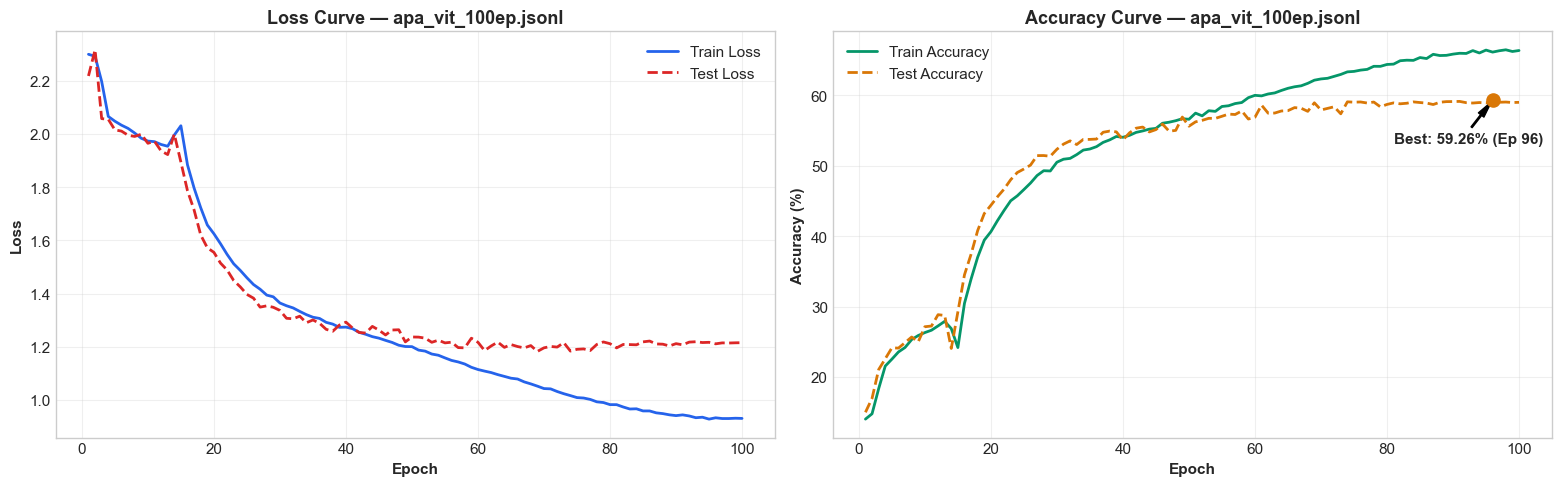

In [4]:
if not df_epochs.empty and 'train_loss' in df_epochs.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    # 1. Loss Curve
    ax1.plot(df_epochs['epoch'], df_epochs['train_loss'], label='Train Loss', color='#2563EB', linewidth=2)
    if 'test_loss' in df_epochs.columns:
        ax1.plot(df_epochs['epoch'], df_epochs['test_loss'], label='Test Loss', color='#DC2626', linewidth=2, linestyle='--')
    ax1.set_xlabel('Epoch', fontweight='bold')
    ax1.set_ylabel('Loss', fontweight='bold')
    ax1.set_title(f'Loss Curve — {os.path.basename(SELECTED_FILE)}', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Accuracy Curve
    if 'train_acc' in df_epochs.columns:
        ax2.plot(df_epochs['epoch'], df_epochs['train_acc'] * 100, label='Train Accuracy', color='#059669', linewidth=2)
    if 'test_acc' in df_epochs.columns:
        ax2.plot(df_epochs['epoch'], df_epochs['test_acc'] * 100, label='Test Accuracy', color='#D97706', linewidth=2, linestyle='--')
        best_acc = df_epochs['test_acc'].max() * 100
        best_ep = df_epochs.loc[df_epochs['test_acc'].idxmax(), 'epoch']
        ax2.scatter([best_ep], [best_acc], color='#D97706', s=90, zorder=5)
        ax2.annotate(f'Best: {best_acc:.2f}% (Ep {int(best_ep)})', 
                     xy=(best_ep, best_acc), xytext=(max(1, best_ep - 15), best_acc - 6),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                     fontweight='bold')
    ax2.set_xlabel('Epoch', fontweight='bold')
    ax2.set_ylabel('Accuracy (%)', fontweight='bold')
    ax2.set_title(f'Accuracy Curve — {os.path.basename(SELECTED_FILE)}', fontsize=13, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
elif not df_steps.empty:
    plt.figure(figsize=(10, 4))
    plt.plot(df_steps['step'], df_steps['loss'], label='Step Loss', color='#2563EB', linewidth=2, marker='.')
    plt.xlabel('Step', fontweight='bold')
    plt.ylabel('Loss', fontweight='bold')
    plt.title(f'Step-Level Training Loss — {os.path.basename(SELECTED_FILE)}', fontsize=13, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 4. Dinamika Evolusi Presisi Temporal (FP8 vs FP16 vs TF32)

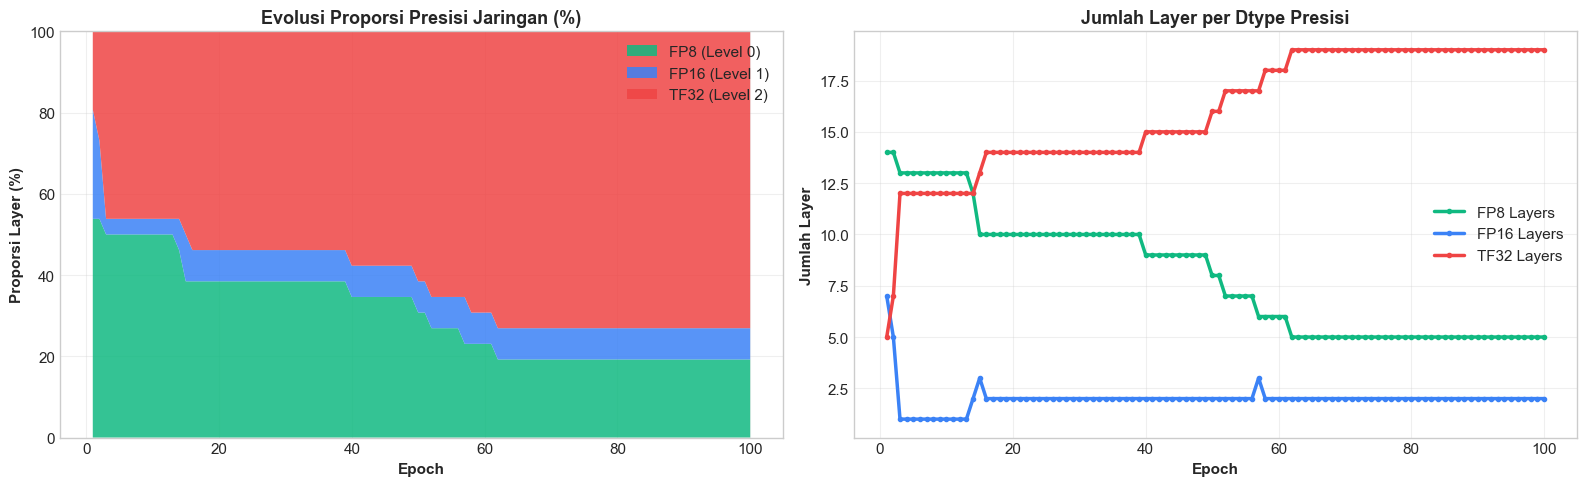

In [5]:
if not df_epochs.empty and 'precision_distribution' in df_epochs.columns:
    dist_records = []
    for _, row in df_epochs.iterrows():
        p = row['precision_distribution']
        if isinstance(p, dict):
            dist_records.append({
                'epoch': row['epoch'],
                'FP8': p.get('fp8', 0),
                'FP16': p.get('fp16', 0),
                'TF32': p.get('tf32', 0)
            })
            
    if dist_records:
        df_dist = pd.DataFrame(dist_records)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
        
        total_l = df_dist['FP8'] + df_dist['FP16'] + df_dist['TF32']
        fp8_p = (df_dist['FP8'] / total_l) * 100
        fp16_p = (df_dist['FP16'] / total_l) * 100
        tf32_p = (df_dist['TF32'] / total_l) * 100
        
        # Stacked Area (% Proportion)
        ax1.stackplot(df_dist['epoch'], fp8_p, fp16_p, tf32_p,
                      labels=['FP8 (Level 0)', 'FP16 (Level 1)', 'TF32 (Level 2)'],
                      colors=['#10B981', '#3B82F6', '#EF4444'], alpha=0.85)
        ax1.set_xlabel('Epoch', fontweight='bold')
        ax1.set_ylabel('Proporsi Layer (%)', fontweight='bold')
        ax1.set_ylim(0, 100)
        ax1.set_title('Evolusi Proporsi Presisi Jaringan (%)', fontsize=13, fontweight='bold')
        ax1.legend(loc='upper right')
        ax1.grid(True, alpha=0.3)
        
        # Absolute counts
        ax2.plot(df_dist['epoch'], df_dist['FP8'], label='FP8 Layers', color='#10B981', linewidth=2.5, marker='.')
        ax2.plot(df_dist['epoch'], df_dist['FP16'], label='FP16 Layers', color='#3B82F6', linewidth=2.5, marker='.')
        ax2.plot(df_dist['epoch'], df_dist['TF32'], label='TF32 Layers', color='#EF4444', linewidth=2.5, marker='.')
        ax2.set_xlabel('Epoch', fontweight='bold')
        ax2.set_ylabel('Jumlah Layer', fontweight='bold')
        ax2.set_title('Jumlah Layer per Dtype Presisi', fontsize=13, fontweight='bold')
        ax2.legend(loc='center right')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
else:
    print("ℹ️ File ini adalah Pure FP32 Baseline atau tidak memiliki telemetry precision_distribution per-epoch.")

## 5. Rincian Event Eskalasi (Jika Ada)

🔥 Total 40 event eskalasi tercatat:


,step,module,reason,old_level,new_level,trigger_value
0,212,blocks.0.mha.out_proj,SILENT_UNDERFLOW,0,1,0.419270
1,212,blocks.0.mlp.2,SILENT_UNDERFLOW,0,1,0.417588
2,212,blocks.1.mha.out_proj,SILENT_UNDERFLOW,0,1,0.419270
3,212,blocks.1.mlp.2,SILENT_UNDERFLOW,0,1,0.418102
4,212,blocks.2.mha.out_proj,SILENT_UNDERFLOW,0,1,0.419270
5,212,blocks.2.mlp.2,SILENT_UNDERFLOW,0,1,0.417855
6,212,blocks.3.mha.out_proj,SILENT_UNDERFLOW,0,1,0.419126
7,212,blocks.3.mlp.2,SILENT_UNDERFLOW,0,1,0.418128
8,212,blocks.4.mha.out_proj,SILENT_UNDERFLOW,0,1,0.418983
9,212,blocks.4.mlp.2,SILENT_UNDERFLOW,0,1,0.417885


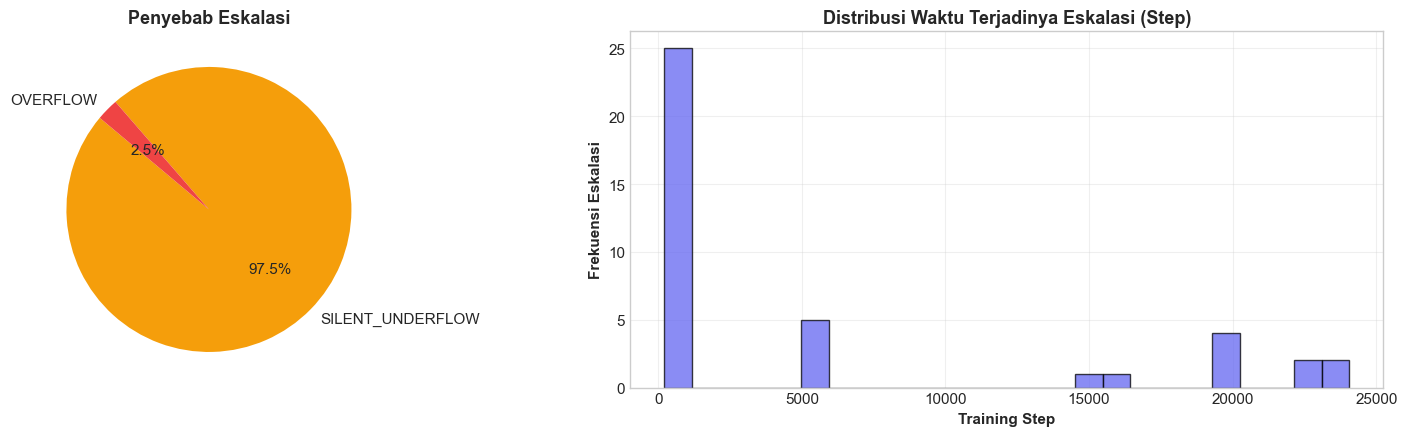

In [6]:
if not df_esc.empty:
    print(f"🔥 Total {len(df_esc)} event eskalasi tercatat:")
    cols = [c for c in ['step', 'module', 'reason', 'old_level', 'new_level', 'trigger_value'] if c in df_esc.columns]
    display(df_esc[cols].head(15))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.5))
    
    # Reasons breakdown
    rc = df_esc['reason'].value_counts()
    ax1.pie(rc, labels=rc.index, autopct='%1.1f%%', colors=['#F59E0B', '#EF4444', '#8B5CF6'], startangle=140)
    ax1.set_title('Penyebab Eskalasi', fontsize=13, fontweight='bold')
    
    # Step histogram
    ax2.hist(df_esc['step'], bins=25, color='#6366F1', edgecolor='black', alpha=0.75)
    ax2.set_xlabel('Training Step', fontweight='bold')
    ax2.set_ylabel('Frekuensi Eskalasi', fontweight='bold')
    ax2.set_title('Distribusi Waktu Terjadinya Eskalasi (Step)', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Tidak ada event eskalasi pada file ini.")

## 6. Peta Presisi Akhir Tiap Layer

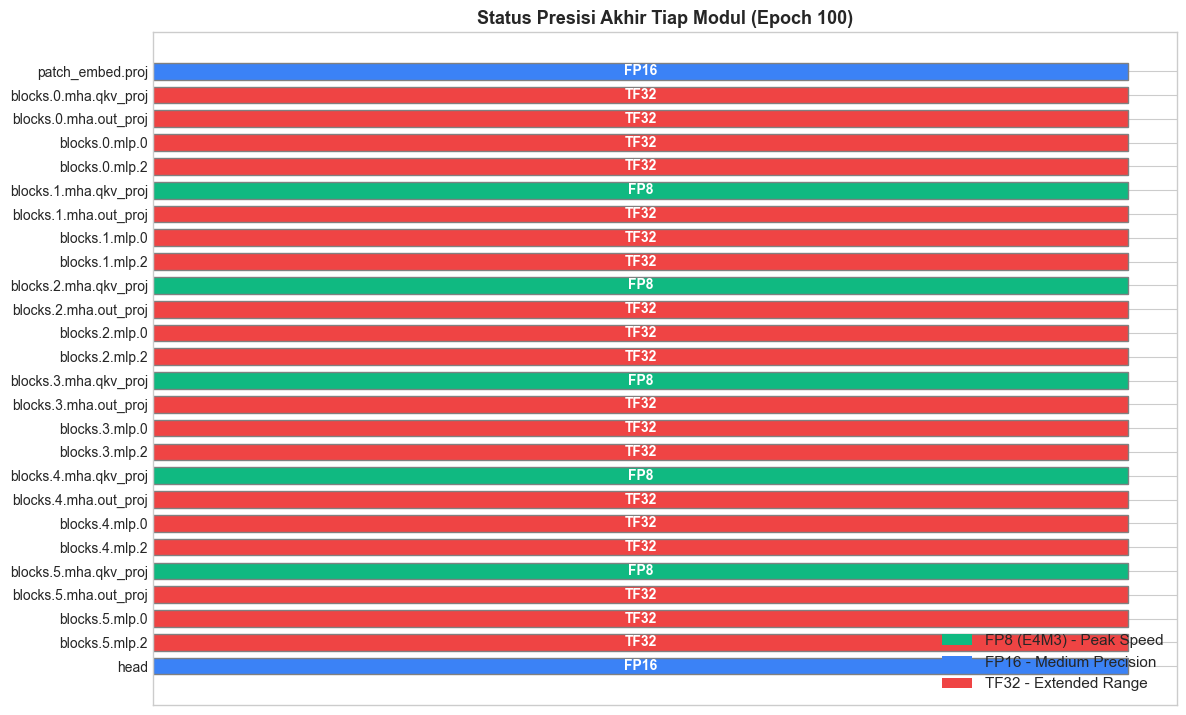

In [7]:
if not df_epochs.empty and 'layer_precisions' in df_epochs.columns:
    last_rec = df_epochs.iloc[-1]
    fl = last_rec['layer_precisions']
    
    if isinstance(fl, dict):
        df_ls = pd.DataFrame(list(fl.items()), columns=['Module', 'Final_Precision'])
        color_m = {'FP8': '#10B981', 'FP16': '#3B82F6', 'TF32': '#EF4444'}
        df_ls['Color'] = df_ls['Final_Precision'].map(color_m)
        
        plt.figure(figsize=(12, max(6, len(df_ls) * 0.28)))
        y_pos = np.arange(len(df_ls))
        plt.barh(y_pos, [1]*len(df_ls), color=df_ls['Color'], edgecolor='grey', height=0.7)
        
        plt.yticks(y_pos, df_ls['Module'], fontsize=10)
        plt.xticks([])
        plt.title(f'Status Presisi Akhir Tiap Modul (Epoch {last_rec.get("epoch", "Final")})', fontsize=13, fontweight='bold')
        
        for idx, r in df_ls.iterrows():
            plt.text(0.5, idx, r['Final_Precision'], ha='center', va='center', color='white', fontweight='bold', fontsize=10)
            
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='#10B981', label='FP8 (E4M3) - Peak Speed'),
            Patch(facecolor='#3B82F6', label='FP16 - Medium Precision'),
            Patch(facecolor='#EF4444', label='TF32 - Extended Range')
        ]
        plt.legend(handles=legend_elements, loc='lower right', framealpha=0.9)
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

## 7. ⚔️ Perbandingan Langsung: APA vs FP32 Baseline

In [8]:
summary_rows = []

for f in jsonl_files:
    h, dfe, dfs, dfes, dfsk = parse_apa_log(f)
    
    mode_name = h.get('mode', 'apa')
    preset = h.get('config', {}).get('apa_preset', h.get('args', {}).get('apa_preset', '-'))
    if mode_name == 'fp32_baseline':
        mode_display = 'FP32 Baseline'
    else:
        mode_display = f'APA ({preset})'
        
    avg_ep_time = f"{dfe['epoch_time_sec'].mean():.2f}s" if not dfe.empty and 'epoch_time_sec' in dfe.columns else '-'
    final_train_loss = f"{dfe['train_loss'].iloc[-1]:.4f}" if not dfe.empty and 'train_loss' in dfe else (f"{dfs['loss'].iloc[-1]:.4f}" if not dfs.empty else '-')
    best_acc = f"{dfe['test_acc'].max()*100:.2f}%" if not dfe.empty and 'test_acc' in dfe else '-'
    
    summary_rows.append({
        'Log File': os.path.basename(f),
        'Mode': mode_display,
        'Epochs/Steps': len(dfe) if not dfe.empty else len(dfs),
        'Avg Time/Epoch': avg_ep_time,
        'Final Loss': final_train_loss,
        'Best Test Acc': best_acc,
        'Escalations': len(dfes),
        'Skips': len(dfsk)
    })

df_comp = pd.DataFrame(summary_rows)
print("🏆 Tabel Ringkasan Eksperimen (APA vs Baseline):")
display(df_comp)

🏆 Tabel Ringkasan Eksperimen (APA vs Baseline):


,Log File,Mode,Epochs/Steps,Avg Time/Epoch,Final Loss,Best Test Acc,Escalations,Skips
0,apa_gpt_log.jsonl,APA (research),10,-,4.0931,-,0,0
1,apa_tf32_test.jsonl,APA (conservative),3,-,3.3632,-,0,0
2,apa_vit_100ep.jsonl,APA (research),100,-,0.9307,59.26%,40,1
3,apa_vit_log.jsonl,APA (research),10,-,2.0139,24.96%,25,1
